<a href="https://colab.research.google.com/github/anjanavedantam/HackHer/blob/main/Hackher.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gradio pandas numpy scikit-learn tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 2.8 MB/s eta 0:00:00


In [2]:
import pandas as pd

from google.colab import files
uploaded = files.upload()
df = pd.read_excel('Food_Expiration_Forecast_Dataset.xlsx')

# Convert dates to datetime format
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])
df['Expiration_Date'] = pd.to_datetime(df['Expiration_Date'])

# Calculate the number of days until expiration (Target variable)
df['Days_To_Expire'] = (df['Expiration_Date'] - df['Purchase_Date']).dt.days

# Preview
df[['Food_Type', 'Temperature_C', 'Humidity_Percent', 'Days_To_Expire']].head()


Saving Food_Expiration_Forecast_Dataset.xlsx to Food_Expiration_Forecast_Dataset.xlsx


,Food_Type,Temperature_C,Humidity_Percent,Days_To_Expire
0,Yogurt,8.542440,61.632297,10
1,Broccoli,9.760351,87.899360,4
2,Carrots,6.885734,72.512120,20
3,Beef,3.536752,77.308662,8
4,Fish,5.232853,88.178137,1


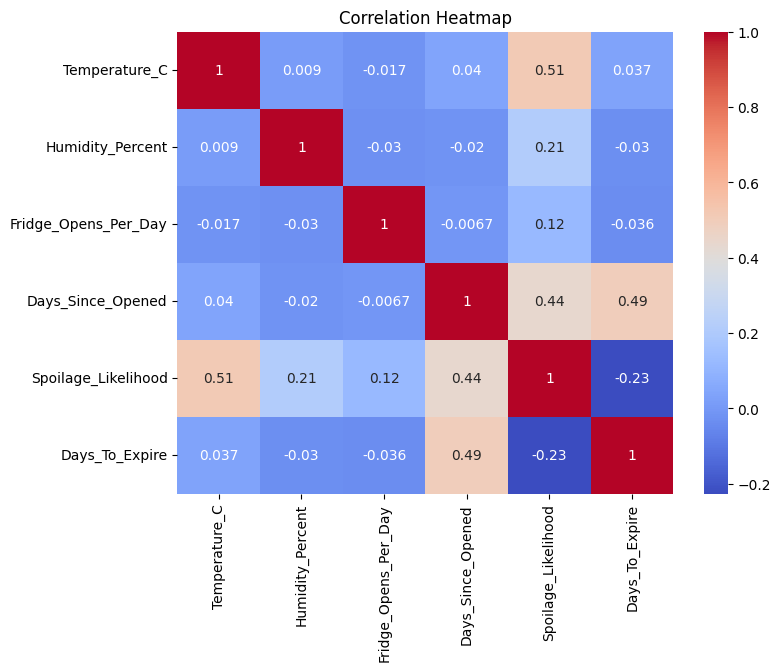

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Food_Type_Encoded'] = le.fit_transform(df['Food_Type'])

# Features and target
X = df[['Food_Type_Encoded', 'Temperature_C', 'Humidity_Percent']]
y = df['Days_To_Expire']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} days")
print(f"R² Score: {r2:.2f}")


Mean Absolute Error: 1.34 days
R² Score: 0.93


In [6]:
def predict_expiration(food_type, temperature, humidity):
    # Encode the food type
    encoded_food = le.transform([food_type])[0]

    # Create input array
    input_features = [[encoded_food, temperature, humidity]]

    # Make prediction
    predicted_days = model.predict(input_features)[0]

    # Round to 2 decimal places
    return round(predicted_days, 2)

# Take user input (capitalize to match training format)
food_input = input("Enter the food item: ").capitalize()
temp_input = float(input("Enter the temperature in Celsius: "))
humidity_input = float(input("Enter the humidity percentage: "))

# Predict expiration days
try:
    if food_input not in [f.capitalize() for f in le.classes_]:
        raise ValueError  # Trigger manual error if not recognized

    prediction = predict_expiration(food_input, temp_input, humidity_input)
    print(f"\n✅ The predicted expiration time for '{food_input}' is: {prediction} days.")

except ValueError:
    print(f"\n❌ Sorry, '{food_input}' is not in the known food list.")
    print("🧾 Here are some valid food types you can try:")
    print(", ".join([f.capitalize() for f in le.classes_]))

Enter the food item: beef
Enter the temperature in Celsius: 17
Enter the humidity percentage: 68

✅ The predicted expiration time for 'Beef' is: 6.14 days.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [7]:
# Install Gradio
!pip install gradio

# Build UI
import gradio as gr

def forecast(food_type, temperature, humidity):
    try:
        prediction = predict_expiration(food_type, temperature, humidity)
        return f"{prediction} days until expiration!"
    except:
        return f"Food type '{food_type}' not recognized. Try one of these:\n{list(le.classes_)}"

demo = gr.Interface(
    fn=forecast,
    inputs=[
        gr.Dropdown(["Milk", "Chicken", "Cheese","Broccoli","Yogurt","Carrots","Beef","Eggs","Fish","Lettuce"], label="Food Item"),
        gr.Slider(0, 15, label="🌡️ Temperature (°C)"),
        gr.Slider(30, 100, label="💧 Humidity (%)")
    ],
    outputs="text",
    title="🧊 Smart Fridge - Food Expiration Forecaster",
    description="Enter food type, temperature, and humidity to predict how many days it will last!",
)

demo.launch()



It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a9b9fab58a6ea4aa72.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
